## Assignment: Object detection
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Put into practice acquired knowledge to detect and recognize objects of interest within a satellite image.

To address this problem, you must choose one of the following options:
*	Implement a sliding window strategy to process the whole image, and then train a classifier that determines whether each window includes or not an object of interest. In this way, you can use previous image classification model to infer the object category.
*	Build a single-stage object detection model (e.g., YOLO, SSD, RetinaNet, etc.).
*	Build a two-stage object detection model (e.g., Faster R-CNN, R-FCN, etc.).

Follow the link below to download the detection data set “xview_detection”: [https://drive.upm.es/s/P7nEf3Bygns7tbM](https://drive.upm.es/s/P7nEf3Bygns7tbM)

In [1]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

2026-04-01 06:34:21.771759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775025261.963018      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775025262.018458      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775025262.432866      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775025262.432915      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775025262.432920      55 computation_placer.cc:177] computation placer alr

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import requests
import zipfile
import json

url = 'https://drive.upm.es/s/P7nEf3Bygns7tbM/download'
zip_name = 'dataset.zip'
target_file = 'xview_det_train.json'
found_path = None

for root, dirs, files in os.walk("."):
    if target_file in files:
        found_path = os.path.join(root, target_file)
        break

if not found_path:
    if not os.path.exists(zip_name):
        r = requests.get(url, stream=True)
        with open(zip_name, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024):
                f.write(chunk)

    if os.path.getsize(zip_name) < 10000:
        print(f"ERREUR : Le fichier {zip_name} est trop petit. Le lien est invalide ou nécessite une connexion.")
    else:
        # Extraction uniquement si le fichier json n'avait pas été trouvé
        with zipfile.ZipFile(zip_name, 'r') as z:
            z.extractall(".")

        for root, dirs, files in os.walk("."):
            if target_file in files:
                found_path = os.path.join(root, target_file)
                break

if found_path:
    print(f"SUCCÈS : Fichier trouvé à : {found_path}")
    
    with open(found_path) as ifs:
        json_data = json.load(ifs)
    print("Base de données chargée avec succès !")
else:
    print(f"ERREUR : {target_file} reste introuvable après extraction.")

SUCCÈS : Fichier trouvé à : ./xview_det_train.json
Base de données chargée avec succès !


In [3]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [4]:
categories = {0: 'Small car', 1: 'Bus', 2: 'Truck', 3: 'Building'}

In [5]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    full_path = os.path.join(BASE_DIR, filename) if ('BASE_DIR' in globals() and BASE_DIR is not None) else filename
    with rasterio.open(full_path, 'r') as src_raster:
        input_type = src_raster.profile['dtype']
        input_channels = src_raster.count
        img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
        for band in range(input_channels):
            img[:, :, band] = src_raster.read(band+1)
    return img

#### Training
Design and train a detector to deal with the “xview_detection” perception task.

In [6]:
import json
import os

json_file = found_path if ('found_path' in globals() and found_path is not None) else '../PROJECT/xview_detection/xview_det_train.json'
if not os.path.exists(json_file):
    raise FileNotFoundError(f"Le fichier json de dataset est introuvable: {json_file}")

with open(json_file) as ifs:
    json_data = json.load(ifs)

BASE_DIR = os.path.dirname(json_file)
print("BASE_DIR:", BASE_DIR)

BASE_DIR: .


In [7]:
import numpy as np
from collections import defaultdict

# Pre-index O(N) au lieu de O(N×M)
ann_index = defaultdict(list)
for ann_elem in json_data['annotations'].values():
    ann_index[ann_elem['image_id']].append(ann_elem)

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img in json_data['images'].values():
    image = GenericImage(json_img['filename'])
    img_h = json_img['height']
    img_w = json_img['width']
    image.tile = np.array([0, 0, img_w, img_h])
    for json_ann in ann_index[json_img['image_id']]:
        obj = GenericObject()
        obj.id = json_ann['image_id']
        x, y, w, h = json_ann['bbox']
        # Clip coordinates to image boundaries
        xmin = max(0, x)
        ymin = max(0, y)
        xmax = min(img_w, x + w)
        ymax = min(img_h, y + h)
        obj.bb = (xmin, ymin, xmax, ymax)
        obj.category = json_ann['category_id']
        counts[obj.category] += 1
        image.add_object(obj)
    anns.append(image)
print(counts)

# Vérification finale (optionnelle)
for img_ann in anns:
    for obj in img_ann.objects:
        xmin, ymin, xmax, ymax = obj.bb
        assert xmin >= 0 and ymin >= 0 and xmax <= img_ann.tile[2] and ymax <= img_ann.tile[3], \
            f"Boîte hors limites : {obj.bb}"

{'Small car': 188300, 'Bus': 6269, 'Truck': 10600, 'Building': 275943}


In [8]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 6845
Number of validation images: 761


In [ ]:
import keras_cv

print('Loading YOLO model...')

BACKBONE = "yolo_v8_m_backbone_coco"

prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format='xyxy',
    from_logits=False,
    confidence_threshold=0.25,
    iou_threshold=0.45
)

model = keras_cv.models.YOLOV8Detector.from_preset(
    preset=BACKBONE,
    num_classes=len(categories),
    bounding_box_format='xyxy',
    prediction_decoder=prediction_decoder
)

print(f"Model loaded: {BACKBONE}")
print(f"Number of classes: {len(categories)}")
model.summary()

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

LEARNING_RATE = 1e-4

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    classification_loss="focal",
    box_loss="ciou",
    jit_compile=False
)

print(f"Model compiled with lr={LEARNING_RATE}")
print("Using default focal loss for classification (no custom loss)")

In [ ]:
from tensorflow.keras.callbacks import (
    TerminateOnNaN, EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, LearningRateScheduler
)

def lr_schedule(epoch, lr):
    warmup_epochs = 3
    if epoch < warmup_epochs:
        return LEARNING_RATE * (epoch + 1) / warmup_epochs
    else:
        import math
        total_epochs = 20
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return LEARNING_RATE * 0.5 * (1 + math.cos(math.pi * progress))

callbacks = [
    ModelCheckpoint(
        'yolo_best.keras',
        monitor='val_loss',
        verbose=1,
        save_best_only=True,
        save_weights_only=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-6
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        verbose=1,
        restore_best_weights=True
    ),
    LearningRateScheduler(lr_schedule, verbose=1),
    TerminateOnNaN()
]

print("Callbacks configured with warmup schedule")

In [ ]:
import tensorflow as tf
import numpy as np

IMG_SIZE = 640

def load_and_preprocess_image(filename):
    """Charge et prétraite une image."""
    def _load(filepath):
        image = load_geoimage(filepath.numpy().decode('utf-8'))
        return tf.cast(image, tf.float32)

    img = tf.py_function(func=_load, inp=[filename], Tout=tf.float32)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img

def create_dataset_element(filename, tile, bboxes, class_ids):
    """Crée un élément de dataset avec le bon format."""
    image = load_and_preprocess_image(filename)

    orig_h = tf.cast(tile[3], tf.float32)
    orig_w = tf.cast(tile[2], tf.float32)

    scale_x = IMG_SIZE / orig_w
    scale_y = IMG_SIZE / orig_h

    scaled_bboxes = tf.stack([
        bboxes[:, 0] * scale_x,
        bboxes[:, 1] * scale_y,
        bboxes[:, 2] * scale_x,
        bboxes[:, 3] * scale_y,
    ], axis=1)

    scaled_bboxes = tf.clip_by_value(scaled_bboxes, 0.0, IMG_SIZE)

    return {
        'images': image,
        'bounding_boxes': {
            'boxes': scaled_bboxes,
            'classes': tf.cast(class_ids, tf.float32)
        }
    }

def dict_to_tuple(inputs):
    """Convertit le dict en tuple pour model.fit()."""
    return inputs['images'], inputs['bounding_boxes']

In [ ]:
import tensorflow as tf
from keras_cv import bounding_box

def extract_data(anns_list):
    filenames = []
    tiles = []
    all_bboxes = []
    all_classes = []

    cat_keys = list(categories.keys())
    cat_vals = list(categories.values())

    for img_ann in anns_list:
        filenames.append(img_ann.filename)
        tiles.append(list(img_ann.tile))

        img_bboxes = []
        img_classes = []
        for obj in img_ann.objects:
            img_bboxes.append(list(obj.bb))
            class_idx = cat_vals.index(obj.category)
            img_classes.append(class_idx)

        all_bboxes.append(img_bboxes)
        all_classes.append(img_classes)

    return filenames, tiles, all_bboxes, all_classes

filenames_train, tiles_train, bboxes_train, classes_train = extract_data(anns_train)
filenames_valid, tiles_valid, bboxes_valid, classes_valid = extract_data(anns_valid)

max_boxes_train = max(len(b) for b in bboxes_train)
max_boxes_valid = max(len(b) for b in bboxes_valid)
MAX_BOXES = max(max_boxes_train, max_boxes_valid)
print(f"Max boxes per image: {MAX_BOXES}")

bboxes_train_padded = [b + [[0, 0, 0, 0]] * (MAX_BOXES - len(b)) for b in bboxes_train]
classes_train_padded = [c + [-1] * (MAX_BOXES - len(c)) for c in classes_train]
bboxes_valid_padded = [b + [[0, 0, 0, 0]] * (MAX_BOXES - len(b)) for b in bboxes_valid]
classes_valid_padded = [c + [-1] * (MAX_BOXES - len(c)) for c in classes_valid]

ds_train = tf.data.Dataset.from_tensor_slices((
    tf.constant(filenames_train),
    tf.constant(tiles_train, dtype=tf.int32),
    tf.constant(bboxes_train_padded, dtype=tf.float32),
    tf.constant(classes_train_padded, dtype=tf.float32)
))

ds_valid = tf.data.Dataset.from_tensor_slices((
    tf.constant(filenames_valid),
    tf.constant(tiles_valid, dtype=tf.int32),
    tf.constant(bboxes_valid_padded, dtype=tf.float32),
    tf.constant(classes_valid_padded, dtype=tf.float32)
))

ds_train = ds_train.map(create_dataset_element, num_parallel_calls=tf.data.AUTOTUNE)
ds_valid = ds_valid.map(create_dataset_element, num_parallel_calls=tf.data.AUTOTUNE)

BATCH_SIZE = 4

ds_train = ds_train.shuffle(buffer_size=500)
ds_train = ds_train.batch(BATCH_SIZE, drop_remainder=True)
ds_train = ds_train.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

ds_valid = ds_valid.batch(BATCH_SIZE, drop_remainder=True)
ds_valid = ds_valid.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
ds_valid = ds_valid.prefetch(tf.data.AUTOTUNE)

print(f"Training batches: {len(ds_train)}")
print(f"Validation batches: {len(ds_valid)}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

for images, bboxes in ds_train.take(1):
    print(f"Images shape: {images.shape}")
    print(f"Boxes shape: {bboxes['boxes'].shape}")
    print(f"Classes shape: {bboxes['classes'].shape}")

    img = (images[0].numpy() * 255).astype(np.uint8)
    boxes = bboxes['boxes'][0].numpy()
    classes = bboxes['classes'][0].numpy()

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)

    colors = ['red', 'blue', 'green', 'orange']

    for box, cls in zip(boxes, classes):
        if cls < 0:
            continue
        xmin, ymin, xmax, ymax = box
        if xmax - xmin < 1 or ymax - ymin < 1:
            continue

        w = xmax - xmin
        h = ymax - ymin
        color = colors[int(cls) % len(colors)]
        rect = patches.Rectangle(
            (xmin, ymin), w, h,
            linewidth=2,
            edgecolor=color,
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            xmin, ymin - 5,
            f"{categories[int(cls)]}",
            fontsize=8,
            color='white',
            backgroundcolor=color
        )

    ax.set_title(f"Sample training image with {int((classes >= 0).sum())} objects")
    plt.tight_layout()
    plt.show()
    break

In [ ]:
import numpy as np

print('='*60)
print('Starting training...')
print('='*60)

EPOCHS = 15

train_steps = len(ds_train)
valid_steps = len(ds_valid)

print(f"Epochs: {EPOCHS}")
print(f"Train steps/epoch: {train_steps}")
print(f"Valid steps/epoch: {valid_steps}")
print(f"Batch size: {BATCH_SIZE}")

history = model.fit(
    ds_train,
    steps_per_epoch=train_steps,
    validation_data=ds_valid,
    validation_steps=valid_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

best_idx = int(np.argmin(history.history['val_loss']))
best_value = np.min(history.history['val_loss'])
print('='*60)
print(f'Best validation model: epoch {best_idx+1} - val_loss {best_value:.4f}')
print('='*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Valid')
axes[0].set_title('Total Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['box_loss'], label='Train')
axes[1].plot(history.history['val_box_loss'], label='Valid')
axes[1].set_title('Box Loss (CIoU)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['class_loss'], label='Train')
axes[2].plot(history.history['val_class_loss'], label='Valid')
axes[2].set_title('Classification Loss (Focal)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_yolo.png', dpi=150)
plt.show()

In [ ]:
# Learning rate evolution (warmup + cosine decay)
import math

if 'lr' in history.history:
    lrs = history.history['lr']
else:
    lrs = [lr_schedule(e, LEARNING_RATE) for e in range(len(history.history['loss']))]

fig, ax = plt.subplots(1, figsize=(8, 4))
ax.plot(range(1, len(lrs) + 1), lrs, marker='o', color='steelblue', linewidth=2)
ax.axvspan(1, 3.5, alpha=0.1, color='orange', label='Warmup phase')
ax.axvspan(3.5, len(lrs) + 0.5, alpha=0.05, color='blue', label='Cosine decay phase')
ax.set_title('Learning Rate Schedule (Warmup + Cosine Decay)', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lr_schedule.png', dpi=150)
plt.show()

In [ ]:
print("\nQuick prediction check on validation images...")

model.load_weights('yolo_best.keras')

for images, gt_bboxes in ds_valid.take(3):
    predictions = model.predict(images, verbose=0)

    img = (images[0].numpy() * 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Ground truth
    axes[0].imshow(img)
    axes[0].set_title('Ground Truth')
    gt_boxes = gt_bboxes['boxes'][0].numpy()
    gt_classes = gt_bboxes['classes'][0].numpy()
    for box, cls in zip(gt_boxes, gt_classes):
        if cls < 0:
            continue
        xmin, ymin, xmax, ymax = box
        if xmax - xmin < 1:
            continue
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='green', facecolor='none'
        )
        axes[0].add_patch(rect)

    # Predictions
    axes[1].imshow(img)
    axes[1].set_title('Predictions')

    num_det = int(predictions['num_detections'][0])
    pred_boxes = predictions['boxes'][0][:num_det]
    pred_classes = predictions['classes'][0][:num_det]
    pred_conf = predictions['confidence'][0][:num_det]

    print(f"Number of detections: {num_det}")

    for box, cls, conf in zip(pred_boxes, pred_classes, pred_conf):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        axes[1].add_patch(rect)
        axes[1].text(
            xmin, ymin - 5,
            f"{categories[int(cls)]} {conf:.2f}",
            fontsize=8, color='white', backgroundcolor='red'
        )

    plt.tight_layout()
    plt.show()

#### Validation
Compute validation metrics.

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as col
import numpy as np
%matplotlib inline

def area_intersection(boxes, box):
    xmin = np.maximum(np.min(boxes[:, 0::2], axis=1), np.min(box[0::2]))
    ymin = np.maximum(np.min(boxes[:, 1::2], axis=1), np.min(box[1::2]))
    xmax = np.minimum(np.max(boxes[:, 0::2], axis=1), np.max(box[0::2]))
    ymax = np.minimum(np.max(boxes[:, 1::2], axis=1), np.max(box[1::2]))
    w = np.maximum(xmax - xmin + 1.0, 0.0)
    h = np.maximum(ymax - ymin + 1.0, 0.0)
    return w * h

def area_union(boxes, box):
    area_anns = (np.max(box[0::2])-np.min(box[0::2])+1.0) * (np.max(box[1::2])-np.min(box[1::2])+1.0)
    area_pred = (np.max(boxes[:, 0::2], axis=1)-np.min(boxes[:, 0::2], axis=1)+1.0) * (np.max(boxes[:, 1::2], axis=1)-np.min(boxes[:, 1::2], axis=1)+1.0)
    return area_anns + area_pred - area_intersection(boxes, box)

def calc_iou(boxes, box):
    iou = area_intersection(boxes, box) / area_union(boxes, box)
    max_value = np.max(iou)
    max_index = np.argmax(iou)
    return max_value, max_index

def calc_ap(rec, prec):
    # First append sentinel values at the end
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    # Compute the precision envelope
    for i in range(mpre.size-1, 0, -1):
        mpre[i-1] = np.maximum(mpre[i-1], mpre[i])
    # To calculate area under PR curve, look for points where X axis (recall) changes value
    i = np.where(mrec[1:] != mrec[:-1])[0]
    # and sum (\Delta recall) * prec
    ap = np.sum((mrec[i+1] - mrec[i]) * mpre[i+1])
    return ap

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=categories, yticklabels=categories, ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

def draw_precision_recall(precisions, recalls, categories):
    # Draw precision-recall curves for each category
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    plt.axis([0, 1, 0, 1])
    c_dark = list(filter(lambda x: x.startswith('dark'), col.cnames.keys()))
    aps = []
    # Compare categories for a specific algorithm
    for idx in range(len(categories)):
        plt.plot(recalls[idx], precisions[idx], color=c_dark[idx], label=categories[idx], linewidth=4.0)
        aps.append(calc_ap(recalls[idx], precisions[idx]))
    handles, labels = ax.get_legend_handles_labels()
    labels = [str(val + ' [' + "{:.3f}".format(aps[idx]) + ']') for idx, val in enumerate(labels)]
    handles = [h for (ap, h) in sorted(zip(aps, handles), key=lambda x: x[0], reverse=True)]
    labels = [l for (ap, l) in sorted(zip(aps, labels), key=lambda x: x[0], reverse=True)]
    leg = plt.legend(handles, labels, loc='upper right')
    leg.set_zorder(100)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid("on", linestyle="--", linewidth=2.0)
    fig.tight_layout()
    plt.show()

In [ ]:
import numpy as np
from tqdm import tqdm

model.load_weights('yolo_best.keras')

# Rebuild validation dataset for inference (batch_size=1)
ds_valid_inf = tf.data.Dataset.from_tensor_slices((
    tf.constant(filenames_valid),
    tf.constant(tiles_valid, dtype=tf.int32),
    tf.constant(bboxes_valid_padded, dtype=tf.float32),
    tf.constant(classes_valid_padded, dtype=tf.float32)
))
ds_valid_inf = ds_valid_inf.map(create_dataset_element, num_parallel_calls=tf.data.AUTOTUNE)
ds_valid_inf = ds_valid_inf.batch(batch_size=1)
ds_valid_inf = ds_valid_inf.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
ds_valid_inf = ds_valid_inf.prefetch(tf.data.AUTOTUNE)

iterator = iter(ds_valid_inf)
annotations, predictions = {}, {}
for ann in tqdm(anns_valid):
    annotations.setdefault(ann.filename, {})
    predictions.setdefault(ann.filename, {})
    for obj in ann.objects:
        annotations[ann.filename].setdefault(obj.category, {'bbox': []})
        annotations[ann.filename][obj.category]['bbox'].append(obj.bb)
    image, _ = next(iterator)
    y_pred = model.predict(image, verbose=0)
    for i in range(np.squeeze(y_pred['num_detections'])):
        obj = GenericObject()
        bbox = np.squeeze(y_pred['boxes'])[i]
        obj.bb = (bbox[0], bbox[1], bbox[2], bbox[3])
        obj.category = categories[int(np.squeeze(y_pred['classes'])[i])]
        obj.score = np.squeeze(y_pred['confidence'])[i]
        predictions[ann.filename].setdefault(obj.category, {'bbox': [], 'confidence': []})
        predictions[ann.filename][obj.category]['bbox'].append(obj.bb)
        predictions[ann.filename][obj.category]['confidence'].append(obj.score)

In [20]:
threshold = 0.5
default_cls = 'BACKGROUND'
y_true, y_pred = [], []  # confusion matrix
tps, confidences = dict(), dict()  # draw precision-recall curves for each category
for cls in categories.values():
    # Compute TP, FP and FN for each image
    tps[cls], confidences[cls] = [], []
    for f in predictions:
        # Sort 'cls' predictions by confidence for each file
        pred_boxes, pred_confidences = [], []
        if cls in predictions[f].keys():
            for idx in range(len(predictions[f][cls]['bbox'])):
                pred_boxes.append(predictions[f][cls]['bbox'][idx])
                pred_confidences.append(predictions[f][cls]['confidence'][idx])
            sorted_ind = np.argsort(-np.array(pred_confidences))
            pred_boxes = np.array(pred_boxes)[sorted_ind, :]
        pred_boxes = np.array(pred_boxes).astype(float)
        # Define 'cls' annotations for each file
        anno_boxes = []
        if cls in annotations[f].keys():
            anno_boxes = annotations[f][cls]['bbox']
        anno_boxes = np.array(anno_boxes).astype(float)
        # Define horizontal or oriented bounding boxes
        anno_indices = list(range(len(anno_boxes)))
        # Compare a single prediction 'pred_box' with all annotations 'anno_boxes'
        for pred_idx, pred_box in enumerate(pred_boxes):
            # A prediction is correct if its IoU with the ground truth is above the threshold
            iou_value, ann_index = calc_iou(anno_boxes, pred_box) if len(anno_boxes) > 0 else (-1, -1)
            if iou_value > threshold and ann_index in anno_indices:
                # TP
                anno_indices.remove(int(ann_index))
                tps[cls] += [1.0]
                y_true += [cls]
            else:
                # FP
                tps[cls] += [0.0]
                y_true += [default_cls]
            y_pred += [cls]
            confidences[cls] += [pred_confidences[pred_idx]]
        # FN
        y_true += [cls] * len(anno_indices)
        y_pred += [default_cls] * len(anno_indices)
y_true, y_pred = np.array(y_true), np.array(y_pred)

In [ ]:
# Per-class AP, Recall, Precision — bar charts for report
import matplotlib.pyplot as plt
import numpy as np

class_names = list(categories.values())
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AP per class
bars = axes[0].bar(class_names, [ap * 100 for ap in ap_list], color=colors_bar, edgecolor='black', linewidth=0.8)
axes[0].axhline(mean_ap * 100, color='red', linestyle='--', linewidth=2, label=f'mAP = {mean_ap*100:.2f}%')
axes[0].set_title('Average Precision (AP) per Class @ IoU=0.5', fontsize=12)
axes[0].set_ylabel('AP (%)')
axes[0].set_ylim(0, max(max(ap_list) * 100 * 1.3, 5))
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)
for bar, ap in zip(bars, ap_list):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{ap*100:.2f}%', ha='center', va='bottom', fontsize=10)

# Recall & Precision per class
x = np.arange(len(class_names))
width = 0.35
rec_vals  = [recall_list[i][-1] * 100 for i in range(len(class_names))]
prec_vals = [precision_list[i][-1] * 100 for i in range(len(class_names))]
axes[1].bar(x - width/2, rec_vals,  width, label='Recall',    color='#42A5F5', edgecolor='black', linewidth=0.8)
axes[1].bar(x + width/2, prec_vals, width, label='Precision', color='#66BB6A', edgecolor='black', linewidth=0.8)
axes[1].set_title('Recall & Precision per Class @ IoU=0.5', fontsize=12)
axes[1].set_ylabel('%')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names)
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ap_metrics_bar.png', dpi=150)
plt.show()

print(f"\nSummary @ IoU=0.5:")
print(f"  mAP : {mean_ap*100:.2f}%")
for cls, ap, rec, prec in zip(class_names, ap_list, rec_vals, prec_vals):
    print(f"  {cls:<12} AP={ap*100:.2f}%  Recall={rec:.2f}%  Precision={prec:.2f}%")

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

# Compute AP metric
precision_list, recall_list, ap_list = [], [], []
for cls in categories.values():
    sorted_ind = np.argsort(-np.array(confidences[cls]))
    tp = np.cumsum(np.array(tps[cls])[sorted_ind], dtype=float)
    recall = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(np.sum(y_true == cls), np.finfo(np.float64).eps)
    precision = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(list(range(1, np.sum(y_pred == cls)+1)), np.finfo(np.float64).eps)
    ap = calc_ap(recall, precision)
    print('> %s: Recall: %.3f%% Precision: %.3f%% AP: %.3f%%' % (cls, recall[-1]*100, precision[-1]*100, ap*100))
    precision_list.append(precision)
    recall_list.append(recall)
    ap_list.append(ap)
mean_ap = np.mean(ap_list)
print('mAccuracy: %.3f%%' % (accuracy_score(y_true, y_pred)*100))
print('mRecall: %.3f%%' % (recall_score(y_true, y_pred, average='macro', zero_division=1)*100))
print('mPrecision: %.3f%%' % (precision_score(y_true, y_pred, average='macro', zero_division=1)*100))
print('mAP: %.3f%%' % (mean_ap*100))

> Small car: Recall: 0.000% Precision: 0.000% AP: 0.000%
> Bus: Recall: 5.938% Precision: 0.050% AP: 0.017%
> Truck: Recall: 0.000% Precision: 0.000% AP: 0.000%
> Building: Recall: 0.000% Precision: 0.000% AP: 0.000%
mAccuracy: 0.031%
mRecall: 1.188%
mPrecision: 60.010%
mAP: 0.004%


Confusion matrix:
[[    0     0 76062     0     0]
 [17501     0     0     0     0]
 [  602     0    38     0     0]
 [ 1044     0     0     0     0]
 [28717     0     0     0     0]]


/tmp/ipykernel_55/2574756117.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))


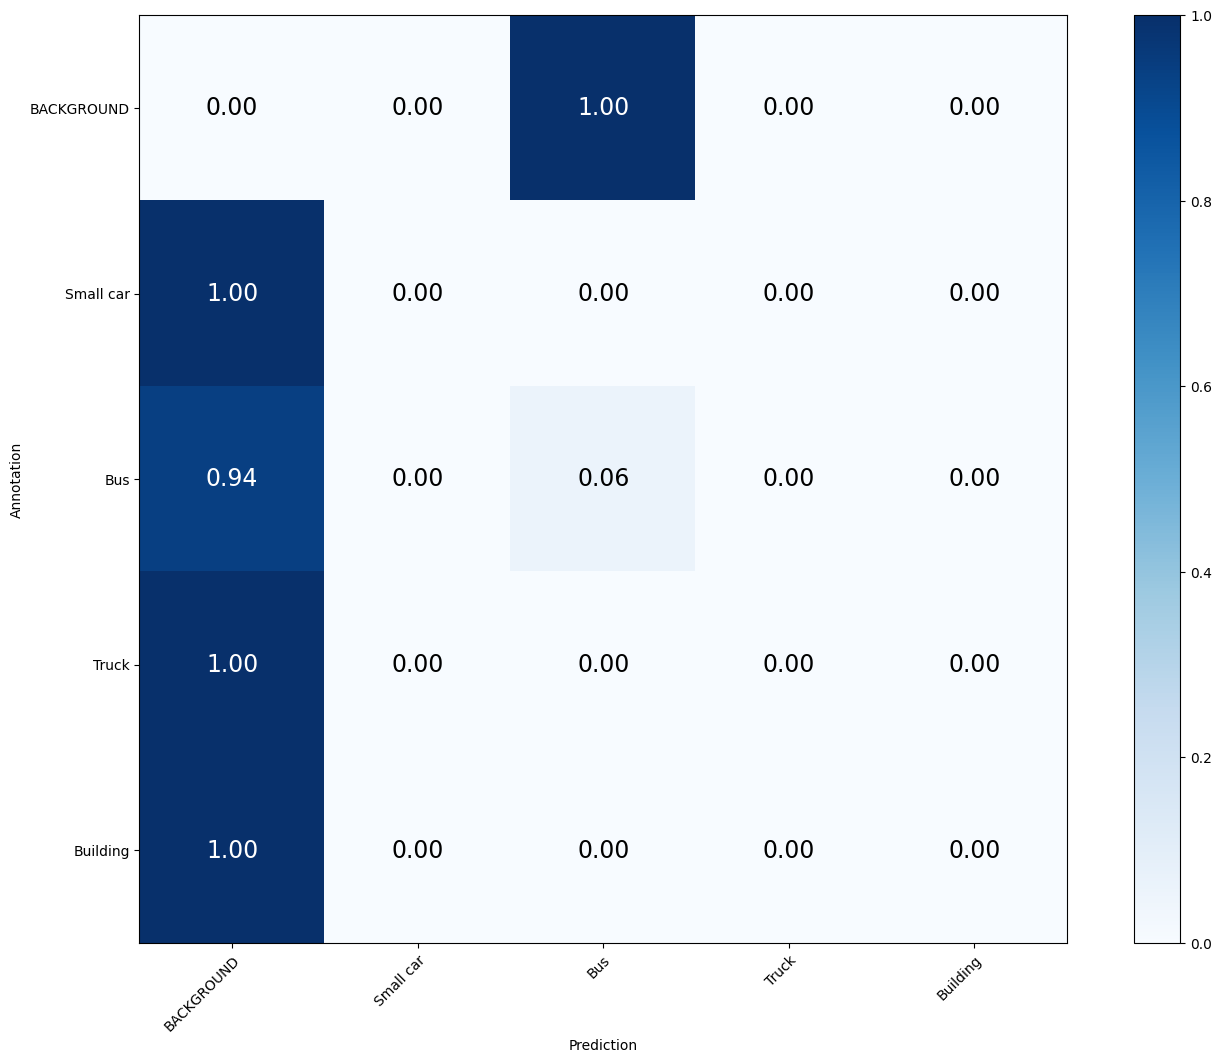

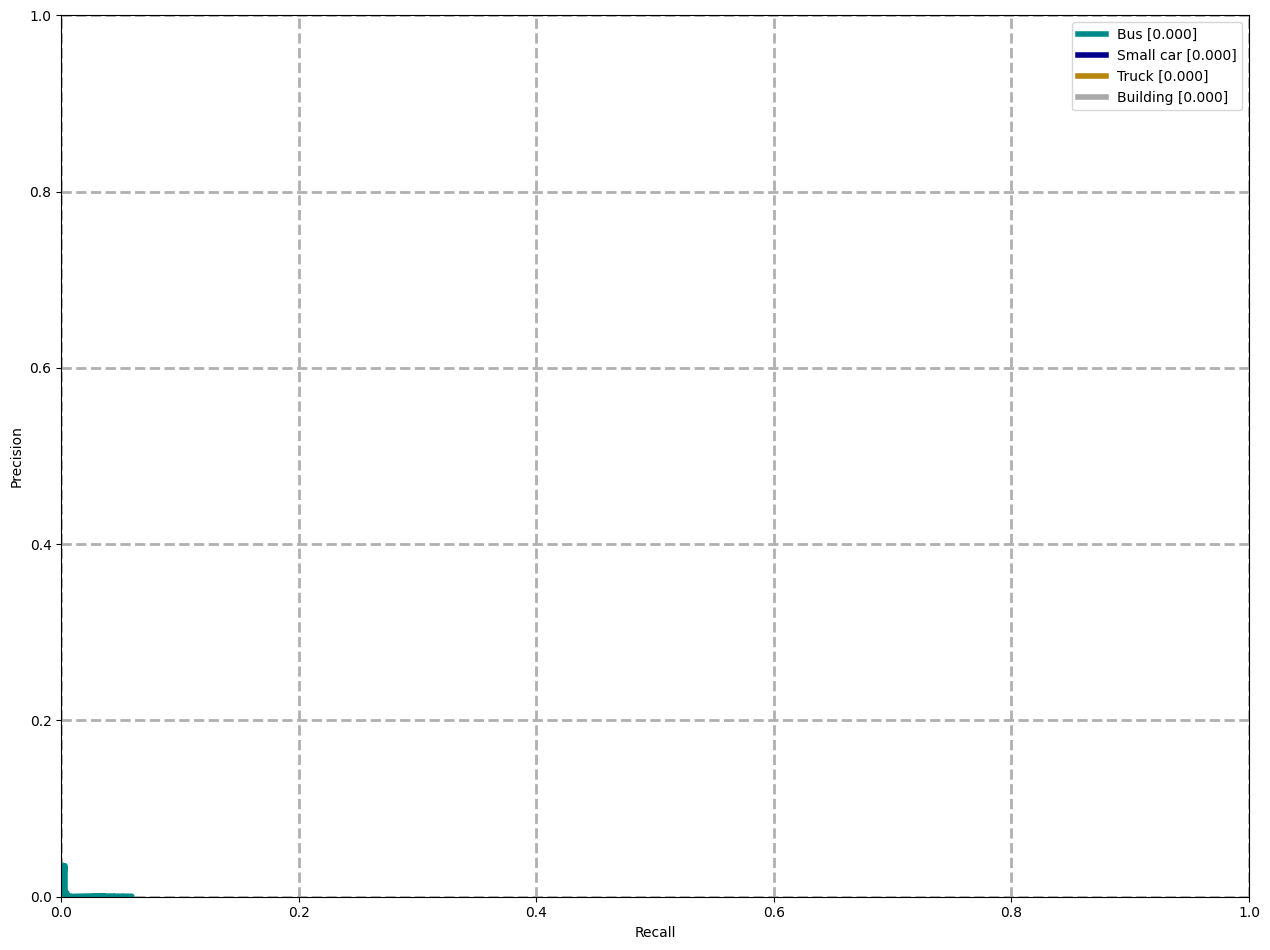

In [22]:
names = list(categories.values()).copy()
names.insert(0, default_cls)
cm = confusion_matrix(y_true, y_pred, labels=names)
print('Confusion matrix:')
print(cm)
draw_confusion_matrix(cm, names)
draw_precision_recall(precision_list, recall_list, categories)

#### Testing
Try to improve the results provided in the competition.

In [23]:
import os
import numpy as np

test_dir = None
for root, dirs, files in os.walk('.'):
    if 'xview_test' in dirs:
        test_dir = os.path.join(root, 'xview_test')
        break

if test_dir is None:
    raise FileNotFoundError("Dossier xview_test introuvable. Vérifie l'extraction du dataset.")

anns = []
for (dirpath, dirnames, filenames) in os.walk(test_dir):
    for filename in filenames:
        # Chemin relatif à partir de la racine du dataset (même convention que le train)
        rel_path = os.path.relpath(os.path.join(dirpath, filename), start='.')
        image = GenericImage(rel_path)
        image.tile = np.array([0, 0, 640, 640])
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 852


In [ ]:
import numpy as np
from tqdm import tqdm

model.load_weights('yolo_best.keras')

# Build test dataset (no annotations)
filenames_test_l = [ann.filename for ann in anns]
tiles_test_l = [list(ann.tile) for ann in anns]
bboxes_test_l = [[[0, 0, 0, 0]] for _ in anns]
classes_test_l = [[-1] for _ in anns]

ds_test = tf.data.Dataset.from_tensor_slices((
    tf.constant(filenames_test_l),
    tf.constant(tiles_test_l, dtype=tf.int32),
    tf.constant(bboxes_test_l, dtype=tf.float32),
    tf.constant(classes_test_l, dtype=tf.float32)
))
ds_test = ds_test.map(create_dataset_element, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(batch_size=1)
ds_test = ds_test.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

iterator = iter(ds_test)
predictions = {}
for ann in tqdm(anns):
    image, _ = next(iterator)
    y_pred = model.predict(image, verbose=0)
    predictions.setdefault(ann.filename, {})
    for i in range(np.squeeze(y_pred['num_detections'])):
        obj = GenericObject()
        bbox = np.squeeze(y_pred['boxes'])[i]
        obj.bb = (bbox[0], bbox[1], bbox[2], bbox[3])
        obj.category = categories[int(np.squeeze(y_pred['classes'])[i])]
        obj.score = np.squeeze(y_pred['confidence'])[i]
        predictions[ann.filename].setdefault(obj.category, {'bbox': [], 'confidence': []})
        predictions[ann.filename][obj.category]['bbox'].append(obj.bb)
        predictions[ann.filename][obj.category]['confidence'].append(obj.score)

# Save prediction
predictions_data = {"images": {}, "annotations": {}, "categories": {}}
predictions_data["categories"] = categories
imgs_idx, annos_idx = 0, 0
for pred in predictions:
    num_objects = sum(len(predictions[pred][cat]['bbox']) for cat in predictions[pred])
    image_data = {"image_id": pred.split('/')[-1], "filename": pred, "num_objects": num_objects, "width": 640, "height": 640}
    predictions_data["images"][imgs_idx] = image_data
    imgs_idx += 1
    for cat in predictions[pred]:
        for i in range(len(predictions[pred][cat]['bbox'])):
            bbox = predictions[pred][cat]['bbox'][i]
            conf = predictions[pred][cat]['confidence'][i]
            annotation_data = {"image_id": pred.split('/')[-1], "category_id": cat, "bbox": (int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])), "confidence": str(conf)}
            predictions_data["annotations"][annos_idx] = annotation_data
            annos_idx += 1

In [25]:
with open("prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)